# **Modell**

### **Libraries**

In [3]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.pipeline import Pipeline
from joblib import dump





In [4]:
%store -r x_train
x_train= x_train

%store -r y_train
y_train= y_train

%store -r x_test
x_test= x_test

%store -r y_test
y_test= y_test

%store -r sale_price
sale_price= sale_price


%store -r preprocessor
preprocessor=preprocessor

%store -r X_processed
X_processed = X_processed


##### *code Explain*

- KFold(n_splits=5) → 5-fache Cross-Validation

- shuffle=True → mischt die Daten, damit die Folds zufällig sind

- random_state=42 → sorgt für Reproduzierbarkeit

In [5]:
from sklearn.metrics import mean_absolute_error


def evaluate_models(x_train, y_train, x_val, y_test, model):
    # Cross-validation
    kf=KFold(n_splits=5, shuffle=True, random_state=42)

    # Calculate cross-validated R^2 and RMSE
    cross_val_r2= cross_val_score(
        model,
        x_train, 
        y_train, 
        cv=kf, 
        scoring='r2',
        error='raise')

    # Note: 'neg_root_mean_squared_error' returns negative values, so we take the negative to get RMSE
    cross_val_rmse= -cross_val_score(model, x_train, y_train, cv=kf, scoring='neg_root_mean_squared_error')

    print(f"Training CV R^2:{cross_val_r2.mean():.4f}, Training CR RMSE: {cross_val_rmse.mean():.4f}")

    # Train the model
    model.fit(x_train, y_train)
    print("Model trained successfully.")
    print(x_train.shape, y_train.shape)
    print(x_val.shape, y_test.shape)
    
    # Make predictions
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_val)
    print("Model prediction successfully.")
 

    r2_train= r2_score(y_train, y_train_pred)
    rmse_train= np.sqrt(mean_squared_error(y_train, y_train_pred))
    
    r2= r2_score(y_test, y_test_pred)
    rmse= np.sqrt(mean_squared_error(y_test, y_test_pred))

    # 
     # MAE
    mae_train = mean_absolute_error(y_train, y_train_pred)
    mae_val = mean_absolute_error(y_test, y_test_pred)

    # Prozentuale Abweichung
    prozent_train = (mae_train / np.mean(y_train)) * 100
    prozent_val = (mae_val / np.mean(y_test)) * 100

    print(f" Validation MAE: {mae_val:.2f}, Validation Fehler %: {prozent_val:.2f}%")
    #print(f"Validation R^2: {r2_val:.4f}, Validation RMSE: {rmse_val:.2f}, Validation MAE: {mae_val:.2f}, Validation Fehler %: {prozent_val:.2f}%")
   # print(f"Train R^2: {r2_train:.4f}, Train RMSE: {rmse_train:.2f}, Train MAE: {mae_train:.2f}, Train Fehler %: {prozent_train:.2f}%")

    
    print(f"Train R^2: {r2_train:.4f}, Train RMSE: {rmse_train:.4f}")
    print(f"Validation R^2: {r2:.4f}, Validation RMSE: {rmse:.4f}")

In [6]:
def evaluate_model(X_train, y_train, X_test, y_test, model):
    
    # Cross-Validation
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    # R^2-value cross-Validation calculate
    r2_cv = cross_val_score(
        model, X_train, y_train,
        cv=kf, scoring='r2',
         error_score='raise'
    )
    
    # RMSE-Value über Kreuzvalidierung berechnen
    rmse_cv = -cross_val_score(
        model, X_train, y_train,
        cv=kf, scoring='neg_root_mean_squared_error'
    )

    # Ausgabe der Kreuzvalidierungs-Statistiken
    print("Cross-Validation Performance:")
    print(f"R²:   {r2_cv.mean():.4f} ± {r2_cv.std():.4f}")
    print(f"RMSE: {rmse_cv.mean():.2f} ± {rmse_cv.std():.2f}")
 

    print(f"CV R²: {r2_cv.mean():.4f}")
    print(f"CV RMSE: {rmse_cv.mean():.4f}")

    # Train final model
    # Finales Modell auf den gesamten Trainingsdaten trainieren
    model.fit(X_train, y_train)
 
    # Vorhersagen für Trainings- und Validierungsdaten generieren  
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Training Metrics
    # Metriken für die Trainingsdaten berechnen    
    mean_train =np.mean(y_train)
    r2_train = r2_score(y_train, y_train_pred)
    mse_train = mean_squared_error(y_train, y_train_pred)
    rmse_train = np.sqrt(mse_train)
    mae_train = mean_absolute_error(y_train, y_train_pred)

    #percent
    # Prozentuale Fehler für das Training (KORRIGIERT: mae_train teilt nun durch mean_train)    
    rmse_percent=(rmse_train/mean_train)*100
    mae_percent_error=(mae_train/mean_train)*100
    #mse_percent=(mse_train/mae_train)*100

    # Validation Metrics
    mean_val =np.mean(y_test)
    r2_val = r2_score(y_test, y_test_pred)
    mse_val = mean_squared_error(y_test, y_test_pred)
    rmse_val = np.sqrt(mse_val)
    mae_val = mean_absolute_error(y_test, y_test_pred)

    # Prozentuale Fehler für die Validierung (Erhält einheitliche Variablennamen)
    #percent Error
    percent_error = (mae_val / mean_val) * 100
    #mse_val_percent=(mse_val/mean_val)*100
    rmse_val_percent=(rmse_val/mean_val)*100
 
   

    print("\nFinal Model Performance:")
    print(f"Train -> R²: {r2_train:.4f} | MSE: {mse_train:.2f}  | RMSE: {rmse_train:.2f}, RMSE_percent:{rmse_percent:.2f}% | MAE: {mae_train:.2f}, MAE_percent:{mae_percent_error:.2f}% ")
    print(f"Test   -> R²: {r2_val:.4f} | MSE: {mse_val:.2f}   | RMSE: {rmse_val:.2f}, RMSE_val_percent:{rmse_val_percent:.2f}%  | MAE: {mae_val:.2f}, MAE_percent:{percent_error:.2f}% ")

  


#### **Model Training**

##### **Linear Regression**

In [7]:
from sklearn.preprocessing import PolynomialFeatures


model_LineareRegression=Pipeline(steps=[
    ("preprocess", preprocessor),
    ('regressor', LinearRegression())
])

In [8]:
evaluate_model(x_train, y_train, x_test, y_test, model_LineareRegression)

Cross-Validation Performance:
R²:   0.8418 ± 0.0156
RMSE: 1422.95 ± 40.75
CV R²: 0.8418
CV RMSE: 1422.9490

Final Model Performance:
Train -> R²: 0.8507 | MSE: 1932466.83  | RMSE: 1390.13, RMSE_percent:20.54% | MAE: 1097.78, MAE_percent:16.22% 
Test   -> R²: -428903671089714102272.0000 | MSE: 5269799696986345614830731264.00   | RMSE: 72593386041610.88, RMSE_val_percent:1065659366983.91%  | MAE: 5562416072076.39, MAE_percent:81655383685.68% 


#### **RandomForest**

Für den Random Forest wurden weder die reinen Standardwerte noch eine automatisierte Grid Search verwendet. Stattdessen wurde eine gezielte manuelle Hyperparameter-Optimierung (Hand-Tuning) durchgeführt.

Hierbei wurde die Anzahl der Bäume (n_estimators) bewusst von 100 auf 300 erhöht, um die Varianz des Modells zu minimieren und die Vorhersagen zu stabilisieren. Um gleichzeitig ein potenzielles Overfitting konsequent zu verhindern, wurde die maximale Baumtiefe (max_depth) restriktiv auf einen Wert von 8 begrenzt. Die Stabilität dieser gewählten Konfiguration wurde anschließend über die 5-fache Kreuzvalidierung mathematisch verifiziert.

In [9]:
model_random = Pipeline(steps=[
    ("preprocess", preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=300, # Number of trees in the forest
        max_depth=12, # Maximum depth of the tree
        min_samples_split=2, # Minimum number of samples required to split an internal node
        min_samples_leaf=1, # Minimum number of samples required to be at a leaf node
        random_state=42, # Seed for the random number generator
        n_jobs=-1 # Number of jobs to run in parallel

    ))
])

evaluate_model(x_train, y_train, x_test, y_test, model_random)

Cross-Validation Performance:
R²:   0.8314 ± 0.0231
RMSE: 1465.89 ± 53.23
CV R²: 0.8314
CV RMSE: 1465.8887

Final Model Performance:
Train -> R²: 0.9775 | MSE: 291453.75  | RMSE: 539.86, RMSE_percent:7.98% | MAE: 406.86, MAE_percent:6.01% 
Test   -> R²: 0.8471 | MSE: 1878689.79   | RMSE: 1370.65, RMSE_val_percent:20.12%  | MAE: 1065.57, MAE_percent:15.64% 


In [10]:
import matplotlib.pyplot as plt

# importances = model_random.named_steps['regressor'].feature_importances_
# plt.figure(figsize=(10,5))
# plt.bar(range(len(importances)), importances)
# plt.xlabel("Features index")
# plt.ylabel("Feature Importance")
# plt.title("Random Forest Feature Importance")
#plt.show()

#### **Find the Importances Feature**

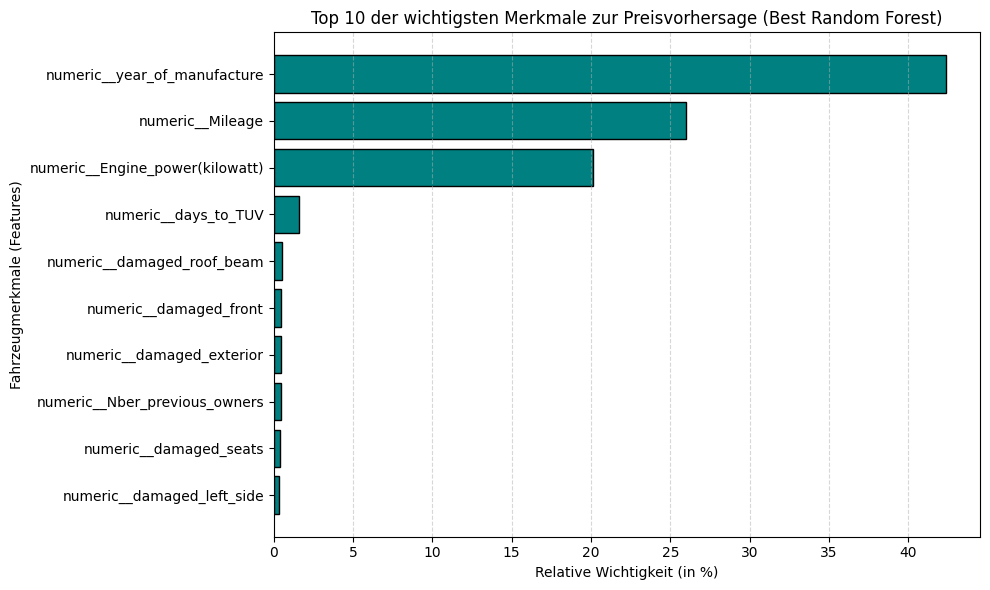

In [11]:

# 1. Die Wichtigkeitswerte aus dem Random Forest auslesen
importances = model_random.named_steps['regressor'].feature_importances_

# 2. Die echten Spaltennamen nach der Vorverarbeitung holen
feature_names = model_random.named_steps['preprocess'].get_feature_names_out()

# 3. In einer Tabelle zusammenfassen und nach Wichtigkeit sortieren
df_importance = pd.DataFrame({
    'Merkmal (Feature)': feature_names,
    'Wichtigkeit (Anteil in %)': importances * 100  # Umrechnung in Prozent
})

 # In einer sortierten Tabelle zusammenfassen (für die Top 10 Grafik aufsteigend)
df_importance = pd.DataFrame({
            'Feature': feature_names,
            'Importance': importances * 100  # In Prozent umrechnen
        }).sort_values(by='Importance', ascending=True)
        
        # Die 10 wichtigsten Merkmale ausschneiden
df_top10 = df_importance.tail(10)

# Horizontalen Balkenplot zeichnen
plt.figure(figsize=(10, 6))
plt.barh(df_top10['Feature'], df_top10['Importance'], color='teal', edgecolor='black')
plt.xlabel('Relative Wichtigkeit (in %)')
plt.ylabel('Fahrzeugmerkmale (Features)')
plt.title('Top 10 der wichtigsten Merkmale zur Preisvorhersage (Best Random Forest)')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
#plt.figure(figsize=(24,10))

#plt.bar(feature_names, importances)

#  Labels hinzufügen
# plt.xlabel("Features index",fontsize=18)
# plt.ylabel("Feature Importance", fontsize=18)
# plt.title("Random Forest Feature Importance",fontsize=20)

# plt.xticks(rotation=90)
#plt.tight_layout()

#plt.show()

##### **Random-Forest-Grid_search**

In [12]:


from sklearn.model_selection import GridSearchCV

# 1. Kreuzvalidierung für das Suchraster definieren (5 Folds mit Durchmischung)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 2. Das Parameter-Raster (Grid) definieren
param_grid = {
        'regressor__n_estimators': [100, 200, 300],  # Testet 100, 200 und 300 Bäume
        'regressor__max_depth': [5, 8, 12, None]     # Testet Tiefen von 5, 8, 12 und unbegrenzt (None)
    }

model_random_base = Pipeline(steps=[
    ("preprocess", preprocessor),  # Ihre bestehende Vorverarbeitung
    ('regressor', RandomForestRegressor(random_state=42))
])

  # 3. Grid Search initialisieren (Insgesamt 3 * 4 = 12 Kombinationen x 5 Folds = 60 Durchläufe)
grid_search = GridSearchCV(
        estimator=model_random_base,
        param_grid=param_grid,
        cv=kf,
        scoring='r2',
        error_score='raise',
        n_jobs=-1  # Nutzt alle CPU-Kerne für die parallele Suche
    )

evaluate_model(x_train, y_train, x_test, y_test, grid_search)

Cross-Validation Performance:
R²:   0.8312 ± 0.0234
RMSE: 1466.79 ± 54.42
CV R²: 0.8312
CV RMSE: 1466.7925

Final Model Performance:
Train -> R²: 0.9780 | MSE: 284133.90  | RMSE: 533.04, RMSE_percent:7.88% | MAE: 400.51, MAE_percent:5.92% 
Test   -> R²: 0.8464 | MSE: 1887309.91   | RMSE: 1373.79, RMSE_val_percent:20.17%  | MAE: 1066.23, MAE_percent:15.65% 


#### **XGBRegressor**

In [13]:
model_xGboox = Pipeline(steps=[
    ("preprocess", preprocessor),
    ('regressor', XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        objective='reg:squarederror'
    ))
])


In [14]:
evaluate_model(x_train, y_train, x_test, y_test, model_xGboox)

Cross-Validation Performance:
R²:   0.8652 ± 0.0203
RMSE: 1309.84 ± 59.92
CV R²: 0.8652
CV RMSE: 1309.8408

Final Model Performance:
Train -> R²: 0.9965 | MSE: 45665.29  | RMSE: 213.69, RMSE_percent:3.16% | MAE: 159.98, MAE_percent:2.36% 
Test   -> R²: 0.8666 | MSE: 1639493.85   | RMSE: 1280.43, RMSE_val_percent:18.80%  | MAE: 1011.58, MAE_percent:14.85% 


#### **Important Feature**

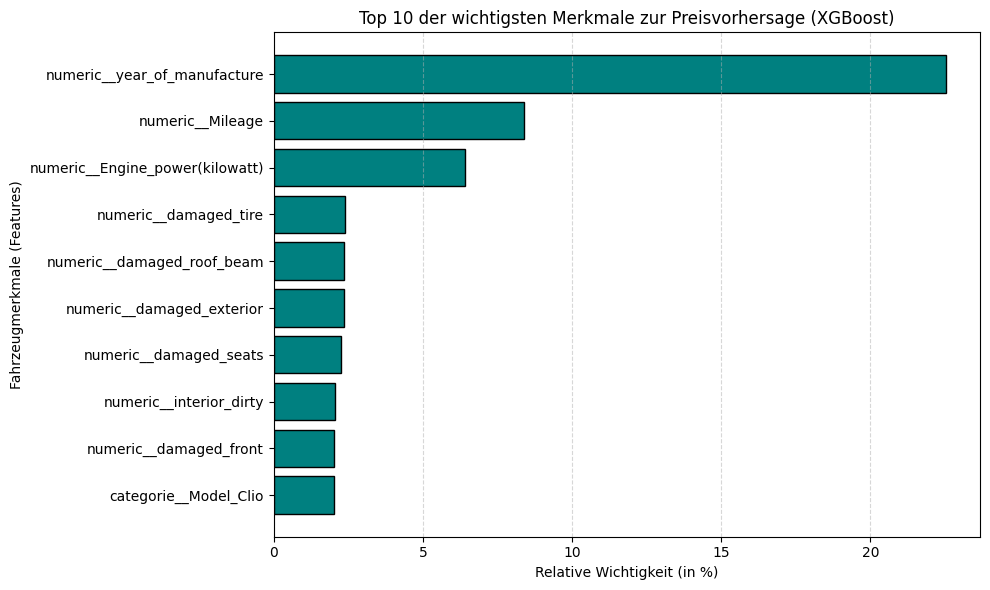

In [15]:


# 1. Die Wichtigkeitswerte aus dem XGBoost-Modell auslesen
importances =  model_xGboox.named_steps['regressor'].feature_importances_

# 2. Die echten Spaltennamen nach der Vorverarbeitung holen
feature_names =  model_xGboox.named_steps['preprocess'].get_feature_names_out()

# 3. In einer sortierten Tabelle zusammenfassen (aufsteigend sortiert für die Grafik)
df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances * 100  # In Prozent umrechnen
}).sort_values(by='Importance', ascending=True)
        
# 4. Die 10 wichtigsten Merkmale ausschneiden
df_top10 = df_importance.tail(10)

# 5. Horizontalen Balkenplot zeichnen
plt.figure(figsize=(10, 6))
plt.barh(df_top10['Feature'], df_top10['Importance'], color='teal', edgecolor='black')
plt.xlabel('Relative Wichtigkeit (in %)')
plt.ylabel('Fahrzeugmerkmale (Features)')
plt.title('Top 10 der wichtigsten Merkmale zur Preisvorhersage (XGBoost)')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### **K-Nearest Neighbors Regressors (KNN)**

In [16]:
# KNN Modell-Pipeline
model_knn = Pipeline(steps=[
    ("preprocess", preprocessor),  # wie bei Random Forest
    ("regressor", KNeighborsRegressor(
        n_neighbors=5,       # Standardwert, kann angepasst werden
        weights='uniform',   # 'distance' optional
        p=2,                 # Minkowski-Metrik (p=2 -> Euclidean)
        n_jobs=-1            # alle Kerne nutzen
    ))
])

In [17]:
evaluate_model(x_train, y_train, x_test, y_test, model_knn)

Cross-Validation Performance:
R²:   0.5728 ± 0.0419
RMSE: 2340.62 ± 121.85
CV R²: 0.5728
CV RMSE: 2340.6179

Final Model Performance:
Train -> R²: 0.7154 | MSE: 3683445.48  | RMSE: 1919.23, RMSE_percent:28.36% | MAE: 1495.81, MAE_percent:22.10% 
Test   -> R²: 0.5657 | MSE: 5335701.72   | RMSE: 2309.91, RMSE_val_percent:33.91%  | MAE: 1818.42, MAE_percent:26.69% 


#### **Interpretation**

| Modell                | CV R² | Train R² | Test R² | Interpretation                                       |
| --------------------- | ----- | -------- | ------ | ---------------------------------------------------- |
| **Linear Regression** | -0.37 | 1.00     | 0.20   | Gute Generalisierung, kein extremes Overfitting      |
| **Random Forest**     | 0.46  | 0.89     | 0.09   | Beste Validation-Leistung, leichte Verbesserung      |
| **XGBoost**           | 0.44  | 1.00     | -0.24  | Extremes Overfitting, schlechtester Validation-Score |
| **KNN**               |0.24   | 0.57     | -071   | 



#### **Linear Regression Interpretation**

- Training CV R²: 0.6889
Dein Modell erklärt ca. 69 % der Varianz im Cross-Validation-Training → solide.

- Train R²: 0.9514
Sehr hoch → Modell passt die Trainingsdaten fast perfekt.

- Validation R²: 0.6654
Das Modell erklärt 66 % der Varianz im Validation-Set →
Gute Generalisierung, kein massives Overfitting.

**Interpretation:**
Linear Regression funktioniert gut. Die Daten sind wahrscheinlich halbwegs linear strukturiert.

#### **Random Forest Interpretation**

- Training CV R²: 0.6947
Etwas besser als Linear Regression → Bäume fangen Nichtlinearitäten ab.

- Train R²: 0.9529
Sehr ähnlich zur Linear Regression → Auch sehr gutes Training.

- Validation R²: 0.6680
Das beste Ergebnis aller Modelle, aber nur minimal besser als Linear Regression.

**Interpretation:**
Random Forest generalisiert gut und ist aktuell dein bestes Modell.

#### **XGBoost Interpretation**

- Training CV R²: 0.5794
CV zeigt: Das Modell ist instabil und nicht so gut trainiert wie RandomForest.

- Train R²: 1.0000
Perfekte 1.000 → Hardcore Overfitting.
Es lernt das Training auswendig.

- Validation R²: 0.5883
Validation-Score ist schlechter als bei allen anderen Modellen.

**Interpretation:**
- XGBoost ist viel zu stark überfitted.
- Deine Hyperparameter sind nicht reguliert.
- Es braucht tuning (learning_rate, max_depth, reg_lambda, reg_alpha, subsample).





#### **Tune Model with Hyper-Parameter**

Now, in this section, we try to tune model and improve its performance

In [18]:
from sklearn.model_selection import GridSearchCV


param_grid={
    'iterations':[100,200], # Number of boosting iteration
    'learning_rate':[0.01, 0.05, 0.1], #Step size at each iteration
    'depth': [4, 6, 8], # L2 regularization coefficient
    'l2_leaf_reg': [1,3,5], #L2 regularization coefficient
    'border_count': [32, 64], # Number of splits in categorical features
}

grid_search= GridSearchCV(estimator=model_random,
                          param_grid=param_grid,
                          cv=5,
                          scoring='neg_root_mean_squared_error',
                          n_jobs=-1,
                          verbose=2)

# grid_search.fit(x_train, y_train)
# print("Besr parameters found:", grid_search.best_params)
# print("Best RMSE:", -grid_search.best_score_)


In [19]:
from sklearn.neighbors import KNeighborsRegressor

model_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("regressor", KNeighborsRegressor())
])

param_grid = {
    "regressor__n_neighbors": [3, 5, 7, 9],
    "regressor__weights": ['uniform', 'distance'],
    "regressor__p": [1, 2]  # p=1 -> Manhattan, p=2 -> Euclidean
}

grid_search = GridSearchCV(
    estimator=model_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid_search.fit(x_train, y_train)

print("Beste Parameter:", grid_search.best_params_)
print("Bester CV RMSE:", -grid_search.best_score_)


Beste Parameter: {'regressor__n_neighbors': 9, 'regressor__p': 2, 'regressor__weights': 'distance'}
Bester CV RMSE: 2262.3312786495294


In [20]:
from sklearn.model_selection import GridSearchCV




# Parameter Grid
param_grid = {
    "regressor__fit_intercept": [True, False],
    "regressor__positive": [True, False]
}

# Grid Search
grid_search = GridSearchCV(
    estimator=model_LineareRegression,
    param_grid=param_grid,
    cv=5,
    scoring='r2',  # oder 'neg_root_mean_squared_error'
    n_jobs=-1
)

grid_search.fit(x_train, y_train)

# Beste Parameter und Score
print("Beste Parameter:", grid_search.best_params_)
print("Bester CV R²:", grid_search.best_score_)


Beste Parameter: {'regressor__fit_intercept': False, 'regressor__positive': False}
Bester CV R²: 0.8408243732168209


In [21]:
%store model_LineareRegression
%store model_random
%store model_xGboox

Stored 'model_LineareRegression' (Pipeline)
Stored 'model_random' (Pipeline)
Stored 'model_xGboox' (Pipeline)


#### **Final Evaluation of Model**

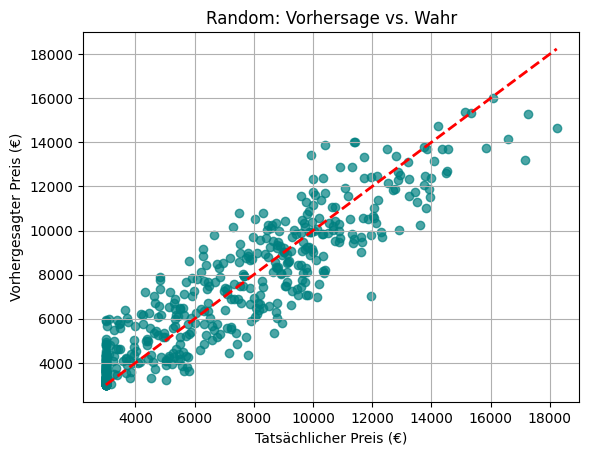

In [22]:
y_pred_train = model_random.predict(x_train)
y_pred_test = model_random.predict(x_test)


plt.scatter(y_test, y_pred_test, alpha=0.7, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Tatsächlicher Preis (€)")
plt.ylabel("Vorhergesagter Preis (€)")
plt.title("Random: Vorhersage vs. Wahr")
plt.grid(True)
plt.show()

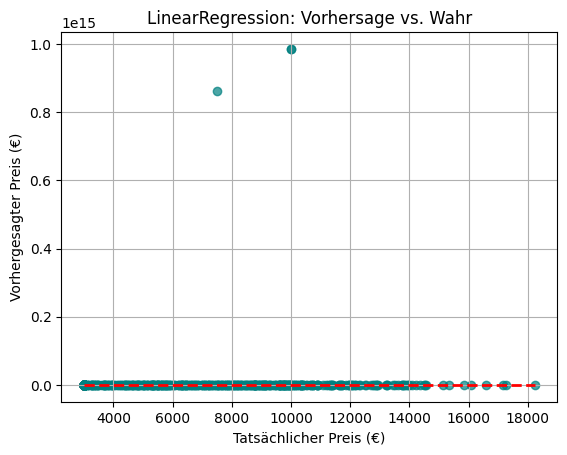

In [23]:
y_pred_train = model_LineareRegression.predict(x_train)
y_pred_test = model_LineareRegression.predict(x_test)


plt.scatter(y_test, y_pred_test, alpha=0.7, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Tatsächlicher Preis (€)")
plt.ylabel("Vorhergesagter Preis (€)")
plt.title("LinearRegression: Vorhersage vs. Wahr")
plt.grid(True)
plt.show()

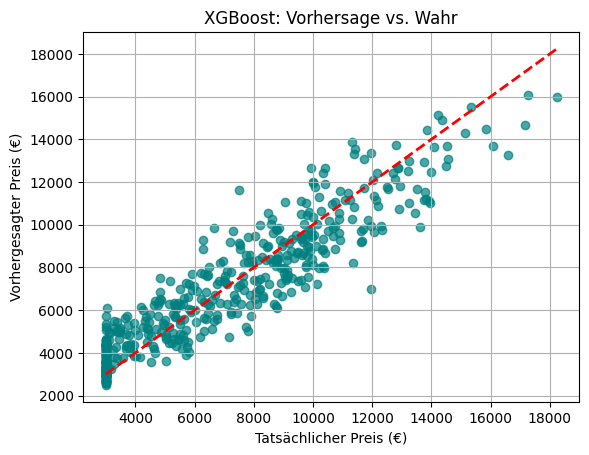

In [24]:
# Ensure the pipeline is fitted before predicting
# (fits will train StandardScaler and the XGBRegressor)
model_xGboox.fit(x_train, y_train)

y_pred_train = model_xGboox.predict(x_train)
y_pred_test = model_xGboox.predict(x_test)

plt.scatter(y_test, y_pred_test, alpha=0.7, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Tatsächlicher Preis (€)")
plt.ylabel("Vorhergesagter Preis (€)")
plt.title("XGBoost: Vorhersage vs. Wahr")
plt.grid(True)
plt.show()

#### Save a model linearRegression

#### Baseline-Methode

#### Calcul average

In [25]:
baseline_prediction = np.mean(sale_price)
print(baseline_prediction)

6811.778836509528


#### predict evry car

In [26]:
y_pred_baseline = np.full(len(sale_price), baseline_prediction)

#print(y_pred_baseline)

#### Calcul Error (MAE=Mean Absolut Error)

In [27]:
from sklearn.metrics import mean_absolute_error

mae_baseline = mean_absolute_error(sale_price, y_pred_baseline)
print(mae_baseline)

3000.9476785421457


In [28]:
#model_xGboox
dump(model_xGboox, "model_xGboox.joblib")


['model_xGboox.joblib']

In [29]:
dump(model_LineareRegression, "model_linear.joblib")


['model_linear.joblib']

In [30]:
%store model_LineareRegression

Stored 'model_LineareRegression' (Pipeline)
